Final EEG shape: (2583, 3, 1001)
Final labels shape: (2583,)


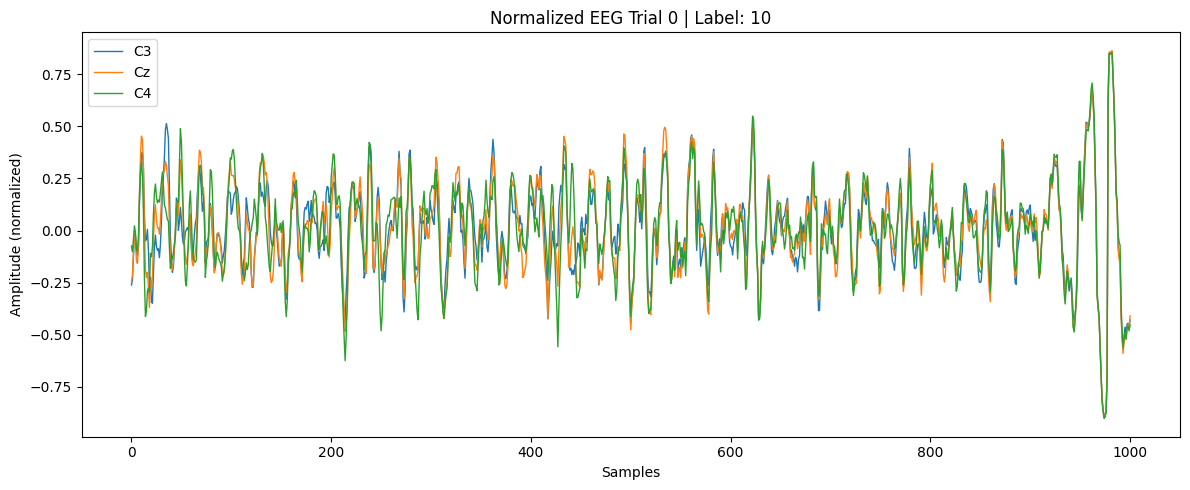

In [ ]:
#                 All subjects: A01-A09

# ==========================================
# PHASE 1: PREPROCESS ALL SUBJECTS
# BCI Competition IV Dataset 2a
# Channels: C3, Cz, C4
# ==========================================

import warnings
import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Suppress known non-critical channel-type warning from GDF reader
warnings.filterwarnings(
    "ignore",
    message="Could not determine channel type of the following channels, they will be set as EEG:*"
 )

# Will store data from all subjects
all_X = []
all_y = []

# Loop through subjects 1 to 9
for subject in range(1, 10):

    # Creates filenames:
    # A01T.gdf, A02T.gdf, ..., A09T.gdf
    file_path = f"BCICIV_2a_gdf\\A{subject:02d}T.gdf"

    # Load EEG recording (suppress reader warnings)
    raw = mne.io.read_raw_gdf(file_path, preload=True, verbose="ERROR")

    # Explicitly mark known EOG channels when present
    eog_channels = ["EOG-left", "EOG-central", "EOG-right"]
    present_eog = {ch: "eog" for ch in eog_channels if ch in raw.ch_names}
    if present_eog:
        raw.set_channel_types(present_eog)

    # Keep only motor cortex channels
    raw.pick(["EEG-C3", "EEG-Cz", "EEG-C4"])

    # Motor imagery frequency range
    raw.filter(8, 30, verbose="ERROR")

    # Extract event markers
    events, event_dict = mne.events_from_annotations(raw, verbose="ERROR")

    # Keep only motor imagery events
    available_events = {
        k: v for k, v in event_dict.items()
        if k in ["769", "770", "771", "772"]
    }

    # Create trials from 2s to 6s after cue
    epochs = mne.Epochs(
        raw,
        events,
        event_id=available_events,
        tmin=2,
        tmax=6,
        baseline=None,
        preload=True,
        verbose="ERROR"
    )

    # EEG data
    X = epochs.get_data()

    # Labels
    y = epochs.events[:, 2]

    # Store current subject
    all_X.append(X)
    all_y.append(y)

# Combine all subjects

X = np.concatenate(all_X, axis=0)
y = np.concatenate(all_y, axis=0)

# Normalize EEG values to [-1, 1]
scaler = MinMaxScaler(feature_range=(-1, 1))
X_flat = X.reshape(-1, X.shape[-1])
X_norm = scaler.fit_transform(X_flat)
X_norm = X_norm.reshape(X.shape)

# Save dataset
np.save("X_preprocessed2.npy", X_norm)
np.save("y.npy", y)

print("Final EEG shape:", X_norm.shape)
print("Final labels shape:", y.shape)

#  visualization: first trial, all three channels
trial_idx = 0
channel_names = ["EEG-C3", "EEG-Cz", "EEG-C4"]

plt.figure(figsize=(12, 5))
for ch_idx, ch_name in enumerate(channel_names):
    plt.plot(X_norm[trial_idx, ch_idx, :], label=ch_name, linewidth=1.0)

plt.title(f"Normalized EEG Trial {trial_idx} | Label: {y[trial_idx]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.legend()
plt.tight_layout()
plt.show()